In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
vocab_size = 10000   # top 10k words
max_len = 200        # padding length

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

In [ ]:
model = models.Sequential()

# Embedding Layer
model.add(layers.Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len))

# LSTM Layer
model.add(layers.LSTM(128, dropout=0.2, recurrent_dropout=0.2))

# Dense Output Layer
model.add(layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 222s 694ms/step - accuracy: 0.7621 - loss: 0.4945 - val_accuracy: 0.7994 - val_loss: 0.4360
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 262s 696ms/step - accuracy: 0.8494 - loss: 0.3550 - val_accuracy: 0.8578 - val_loss: 0.3445
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 217s 692ms/step - accuracy: 0.8904 - loss: 0.2737 - val_accuracy: 0.8636 - val_loss: 0.3507
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 219s 699ms/step - accuracy: 0.9127 - loss: 0.2280 - val_accuracy: 0.8470 - val_loss: 0.3724
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 267s 714ms/step - accuracy: 0.9261 - loss: 0.1948 - val_accuracy: 0.8608 - val_loss: 0.3887


In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

782/782 ━━━━━━━━━━━━━━━━━━━━ 67s 85ms/step - accuracy: 0.8561 - loss: 0.3979
Test Accuracy: 0.8561199903488159
Test Loss: 0.3979073464870453


In [ ]:
plt.figure(figsize=(12,5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

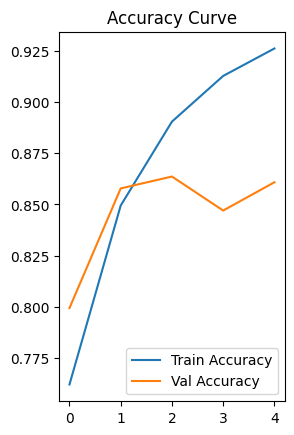

In [ ]:
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy Curve")
plt.legend()

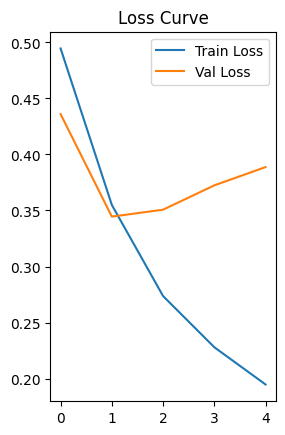

In [ ]:
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Curve")
plt.legend()

plt.show()